# 03 - Baseline Model 

This notebook establishes a logistic regression baseline model using a full sklearn pipeline with preprocessing. This serves as a baseline, setting the performance floor for all subsequent models in `04_model_comparisons.ipynb` to beat in order to justify added complexity. 

**Input:** `data/processed/cleaned_data.csv`
**Output:** Baseline accuracy, classification report, and confusion matrix

In [34]:
# Setup and imports 

import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from src.preprocessing import build_preprocessor

ufc_data = pd.read_csv('../data/processed/cleaned_data.csv')
ufc_data.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,Winner,title_bout,weight_class,...,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds,Red_Win
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,Blue,False,Middleweight,...,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0,0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,Red,False,Women's Flyweight,...,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0,1
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,Red,False,Welterweight,...,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0,1
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,Blue,False,Featherweight,...,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0,0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,Blue,False,Middleweight,...,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0,0


In [36]:
# Drop post-fight columns 

post_fight_cols = [
    'finish',              
    'finish_details',      
    'finish_round',        
    'finish_round_time',   
    'total_fight_time_secs' 
]

odds_cols = [
    'R_odds', 'B_odds', 'R_ev', 'B_ev',
    'r_dec_odds', 'b_dec_odds',
    'r_sub_odds', 'b_sub_odds',
    'r_ko_odds', 'b_ko_odds'
]

id_cols = ['R_fighter', 'B_fighter', 'date', 'Winner']

We need to drop the post-fight statistics and betting odds included in each fight's data as it leaks important information that makes it easier for model to predict the outcome of a fight. 

In [37]:
# Split data training and testing sets 
cols_to_remove = post_fight_cols + odds_cols + id_cols 

X1 = ufc_data.drop(columns=['Red_Win', 'Winner', 'date', 'R_fighter', 'B_fighter'] + cols_to_remove)
y1 = ufc_data['Red_Win']

numeric_cols = X1.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X1.select_dtypes(include=['object', 'category']).columns.tolist()

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

## Preprocessing Pipeline

A `sklearn Pipeline` is used to chain preprocessing and model training into a single 
object, ensuring preprocessing steps only learn from training data and are applied 
consistently to test data — preventing data leakage.

**Numeric features** are passed through two steps:
- `SimpleImputer(strategy='median')` — fills missing values with the column median, 
  robust to outliers common in fight statistics
- `StandardScaler` — scales all numeric features to mean=0, std=1 so no single 
  feature dominates the model due to differences in scale

**Categorical features** (`better_rank`, `weight_class`, `gender`, `R_Stance`, `B_Stance`) 
are passed through:
- `SimpleImputer(strategy='most_frequent')` — fills missing values with the most 
  common category
- `OneHotEncoder` — converts string categories into binary columns since models 
  require numeric input

Both transformers are combined using `ColumnTransformer`, which applies each 
transformer to the appropriate columns simultaneously.

In [41]:
# Create logistic regression model 
preprocessor = build_preprocessor(numeric_cols, categorical_cols)

# Chain into pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

In [39]:
# Train the model 
pipeline.fit(X1_train, y1_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_rounds',
                                                   'B_current_lose_streak',
                                                   'B_current_win_streak',
                                                   'B_draw',
                                                   'B_avg_SIG_STR_landed',
                                                   'B_avg_SIG_STR_pct',
                                                   'B_avg_SUB_ATT',
                                                   'B_avg_TD_landed',
                                                   'B_avg_TD_pct',
                                                   'B_longest_win_streak',
                                                   '...
                                                   'R_current_win_streak',
                                                   'R_draw',
                                                   'R_avg_SIG_STR_landed',
                                                   'R_avg_SIG_STR_pct',
                                                   'R_avg_SUB_ATT',
                                                   'R_avg_TD_landed', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['weight_class', 'gender',
                                                   'B_Stance', 'R_Stance',
                                                   'better_rank'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

Accuracy: 0.634
              precision    recall  f1-score   support

           0       0.59      0.41      0.48       598
           1       0.65      0.79      0.72       838

    accuracy                           0.63      1436
   macro avg       0.62      0.60      0.60      1436
weighted avg       0.63      0.63      0.62      1436



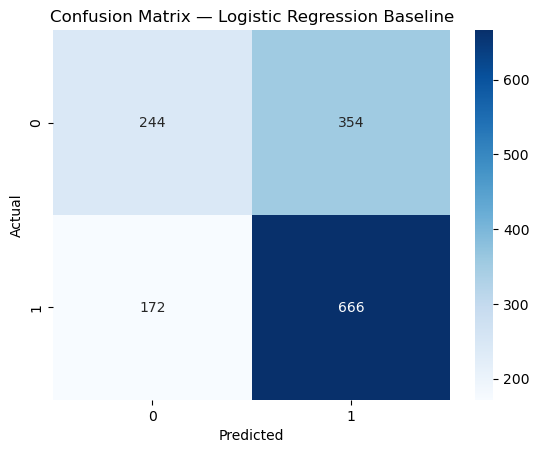

In [40]:
# Evaluate model 

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X1_test)

print(f"Accuracy: {accuracy_score(y1_test, y_pred):.3f}")
print(classification_report(y1_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y1_test, y_pred)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Logistic Regression Baseline')
plt.show()

## Baseline Model Results 

- **Model:** Logistic Regression 
- **Accuracy:** 0.634
- **Notes:** The model seems to be biased to red wins, having a higher precision, recall, and f1-score for red wins compared to blue wins.
- **Benchmark:** Other models must exceed an accuracy of 0.634 and improve Blue win recall to justify any added complexity.